# Predicting P-granule mRNA Stability from Primary Structure Features in Early C. elegans Embryogenesis

## Introduction:

P-granules in the model organism *Caenorhabditis elegans* are enriched with maternally derived mRNAs in the early phases of embryogenesis, but a significant proportion of these transcripts are degraded before reaching primordial germ cells (PGCs). These cells are the embryonic precursors for gametes, which are the responsible for passing genetic information down to offspring. Only a small proportion of stable maternally derived mRNAs are maintained and passed on to the germline, however the mechanisms underlying this process are a topic of ongoing research. P-granule association alone does not determine whether maternally derived mRNAs are maintained or degraded (Scholl et al.). The aim of this project is to investigate whether information found within the primary structure of mRNA is sufficient for predicting the stability of maternally derived mRNAs in P-granules during the early phases of embryogenesis.

### Ground truth dataset:

https://datadryad.org/downloads/file_stream/3243524

### Ground truth data description:

The ground truth dataset contains label information for maternally derived mRNA molecule fate in P-granules during early phase embroyonic development in c. elegans. The dataset was derived from experimentally validated single-molecule fluorescence in situ hybridization (smFISH). Labels are contained within the 'Groups' column, where 'Group I' represents **stable** mRNAs in P-granules and 'Group II' represents **degraded** mRNAs in P-granules.

Preprocessing changes labels to:

Group I = 0 (stable)

Group II = 1 (degraded)

### Feature sets:

This project will explore four different feature sets that were derived from sequence information found in the primary mRNA structure.

1) `kmers_features.csv`: 4-mer count matrix of 3' untranslated region (3'UTR)
2) `utr_length.csv`: 3'UTR lengths
3) `rna_structure.csv`: Minimum free energy of secondary structure with paired and unpaired fractions
4) `lunp_feature_matrix.csv`: Average pair probabilities for locally stable secondary structures



### References:

Alyshia Scholl, Yihong Liu, Geraldine Seydoux; Caenorhabditis elegans germ granules accumulate hundreds of low translation mRNAs with no systematic preference for germ cell fate regulators. Development 1 July 2024; 151 (13): dev202575. doi: https://doi.org/10.1242/dev.202575

Ronny Lorenz, Stephan H. Bernhart, Christian Höner zu Siederdissen, Hakim Tafer, Christoph Flamm, Peter F. Stadler, and Ivo L. Hofacker. ViennaRNA package 2.0. Algorithms for Molecular Biology, 6(1):26, 2011. doi:10.1186/1748-7188-6-26.

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Import labels:

Downstream analysis will merge labels across features sets on WBgene


In [2]:
labels = pd.read_csv('gene_labels.csv')
labels.sort_values(by=['label'], inplace=True)
labels

,WBgene,label
238,WBGene00010232,0
182,WBGene00007297,0
336,WBGene00017826,0
101,WBGene00003865,0
184,WBGene00007352,0
...,...,...
148,WBGene00006406,1
147,WBGene00006386,1
145,WBGene00005025,1
155,WBGene00006604,1


In [3]:
labels.shape

(415, 2)

### Labels:

Based on label counts, we are dealing with an unbalanced dataset with a low number of samples (n = 415). This is an important consideration for downstream analysis as we will have to account for the unbalanced distribution. This will likely cause the model to be more confident at predicting degraded mRNAs.

1 (degraded) = 296 (~71%)

0 (stable) = 119 (~29%)

Total = 415

In [4]:
labels['label'].value_counts()

label
1    296
0    119
Name: count, dtype: int64

#### Fig 1: Distribution of ground-truth labels

Fig 1. visualizes the unbalanced distribution of the target labels in this analysis. The following machine-learning algorithms in this analysis will use `scoring = balanced_accuracy` handle the unbalanced distribution and avoid predicting the majority class, `1: 'Degraded'`

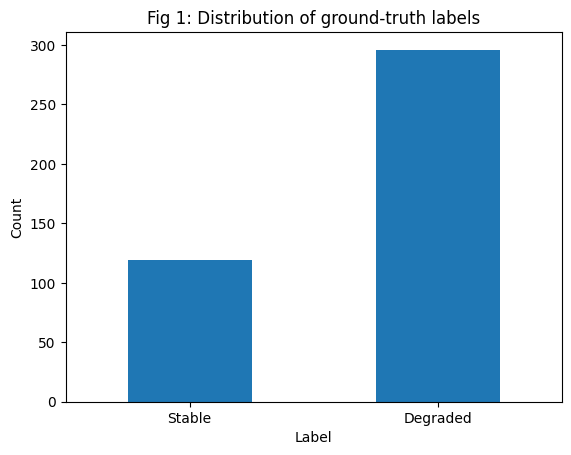

In [5]:
labels['label'].map({0: 'Stable', 1: 'Degraded'}).value_counts().sort_values(ascending=True).plot(kind='bar')
plt.title('Fig 1: Distribution of ground-truth labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### k-mer feature matrix:

This feature matrix contains sequence information from the 3'UTR region of the associated mRNA primary structure.

K-mers are all possible substrings of length k for a given sequence. Since RNA contains 4 nucleotide bases, and k = 4, we will have a total of $4^4 = 256$ features.

While 5-mers or 6-mers might capture more biologically relevant information such as specific RNA-binding protein motifs, the dataset would be extremely sparse. Additionally, using a larger k would exponentially inflate the feature space. Given the low number of samples, 4-mers will be used.

**Example of 4-mer counts from sequence:**

3'UTR sequence = 'ACAACACAA'

4-mer_counts = {'ACAA': 2, 'CAAC': 1, 'AACA': 1, 'ACAC': 1, 'CACA': 1}

The `kmers_features.csv` file is a 4-mer counts matrix containing 460 samples from the original ground-truth dataset. Group III will be excluded as it represents inconclusive smFISH results. Only 415 samples will be retained after merging with the labels dataset.

In [6]:
# Let's look at the data
kmers = pd.read_csv('kmer_features.csv')
kmers

,WBgene,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,aaga,...,ttcg,ttct,ttga,ttgc,ttgg,ttgt,ttta,tttc,tttg,tttt
0,WBGene00000041,6,4,1,3,2,2,0,3,1,...,2,3,3,0,1,4,2,8,3,13
1,WBGene00000064,1,1,0,4,1,0,2,1,0,...,1,1,0,0,1,1,6,2,2,6
2,WBGene00000098,1,2,2,4,1,2,2,1,0,...,2,6,0,0,0,5,6,8,3,7
3,WBGene00000101,1,2,0,3,3,2,1,1,3,...,2,8,4,2,0,3,6,12,3,18
4,WBGene00000168,20,3,3,16,6,2,0,0,2,...,8,5,3,4,4,7,12,22,6,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455,WBGene00022702,1,2,1,3,2,1,1,3,1,...,2,9,3,3,1,3,11,11,5,22
456,WBGene00022703,2,0,2,1,1,0,0,0,0,...,1,1,0,1,0,1,3,2,1,4
457,WBGene00022775,0,3,0,0,2,1,1,1,2,...,1,10,4,1,1,5,4,11,5,22
458,WBGene00022832,7,1,1,1,1,0,0,0,2,...,0,4,0,1,1,4,5,3,2,8


### Note on shape:

The original ground truth dataset includes a 'Group III' label, which inflates the number of rows. As mentioned above, 'Group III' labels were represent inconclusive results in the original study. Merge `how='inner` will handle this by collapsing the dataframe on `WBgene` ids that are only retained in the labels dataframe.

In [7]:
kmers.shape

(460, 257)

In [8]:
kmers_df = pd.merge(labels, kmers, on='WBgene', how='inner')
kmers_df.head(10)

,WBgene,label,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,...,ttcg,ttct,ttga,ttgc,ttgg,ttgt,ttta,tttc,tttg,tttt
0,WBGene00010232,0,0,0,2,2,0,0,0,1,...,1,4,0,1,0,6,1,8,2,8
1,WBGene00007297,0,2,5,1,1,1,0,2,4,...,0,1,1,0,0,2,5,1,2,6
2,WBGene00017826,0,1,1,1,1,1,2,0,0,...,0,2,1,1,0,0,4,5,0,11
3,WBGene00003865,0,0,3,1,4,1,1,1,4,...,0,0,1,4,0,2,4,1,3,6
4,WBGene00007352,0,5,0,1,3,0,1,0,0,...,2,1,4,2,0,3,6,5,4,12
5,WBGene00003830,0,0,1,0,10,2,1,0,2,...,2,7,0,0,0,6,7,12,2,15
6,WBGene00018150,0,6,1,1,6,0,1,0,1,...,1,4,2,0,0,2,3,4,2,11
7,WBGene00011746,0,10,4,2,11,3,4,0,3,...,5,8,5,3,1,5,8,18,5,24
8,WBGene00018421,0,1,1,0,3,1,0,0,2,...,0,6,0,1,0,4,2,3,2,7
9,WBGene00003784,0,0,1,0,1,1,1,0,0,...,0,4,2,0,0,0,5,6,0,7


In [9]:
# Check shape for 415 rows
kmers_df.shape

(415, 258)

### Merge 3'UTR length:

In theory, the k-mer counts matrix should already capture sequence length information in total number of counts per sample. However, explicit 3'UTR length could add a extra sequence level information to the analysis.

In [10]:
utr_length = pd.read_csv('utr_length.csv')

In [11]:
utr_length

,WBgene,UTR_length
0,WBGene00000041,274.0
1,WBGene00000064,165.0
2,WBGene00000098,354.0
3,WBGene00000101,418.0
4,WBGene00000168,771.0
...,...,...
455,WBGene00022702,476.0
456,WBGene00022703,108.0
457,WBGene00022775,532.0
458,WBGene00022832,231.0


In [12]:
utr_length.shape

(460, 2)

Let's explore if there are any clear differences in the mean sequence length for stable and degraded mRNAs in this dataset.

We will use a `utr_length_test` dataset and calculate the mean UTR length for each label.

In [13]:
utr_length_test = pd.merge(labels, utr_length, on='WBgene', how='inner')
utr_length_test

,WBgene,label,UTR_length
0,WBGene00010232,0,202.0
1,WBGene00007297,0,170.0
2,WBGene00017826,0,202.0
3,WBGene00003865,0,296.0
4,WBGene00007352,0,297.0
...,...,...,...
410,WBGene00006406,1,342.0
411,WBGene00006386,1,137.0
412,WBGene00005025,1,268.0
413,WBGene00006604,1,1205.0


There does seem to be a difference in mean UTR length between the two classes

In [14]:
utr_length_test.groupby('label')['UTR_length'].mean()

label
0    340.100840
1    422.712838
Name: UTR_length, dtype: float64

Merge will handle shape

In [15]:
kmers_df = pd.merge(kmers_df, utr_length, on='WBgene', how='inner')
kmers_df.head(5)

,WBgene,label,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,...,ttct,ttga,ttgc,ttgg,ttgt,ttta,tttc,tttg,tttt,UTR_length
0,WBGene00010232,0,0,0,2,2,0,0,0,1,...,4,0,1,0,6,1,8,2,8,202.0
1,WBGene00007297,0,2,5,1,1,1,0,2,4,...,1,1,0,0,2,5,1,2,6,170.0
2,WBGene00017826,0,1,1,1,1,1,2,0,0,...,2,1,1,0,0,4,5,0,11,202.0
3,WBGene00003865,0,0,3,1,4,1,1,1,4,...,0,1,4,0,2,4,1,3,6,296.0
4,WBGene00007352,0,5,0,1,3,0,1,0,0,...,1,4,2,0,3,6,5,4,12,297.0


Now we have 415 rows and an additional column for UTR length

In [16]:
kmers_df.shape

(415, 259)

## Baseline model

### Logistic regression:

Logistic regression is a good model to use as a baseline to compare the performance of Support Vector Machine (SVM) because it is also a linear classifier and handles a binary classification (0 or 1), much like SVM.


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

The first step before running any model is to split the dataset into the features (X) and the labels (y)

In [18]:
X = kmers_df.drop(columns=['WBgene', 'label'])
y = kmers_df['label'].astype(int)

In [19]:
X.shape, y.shape

((415, 257), (415,))

In [20]:
X.head(5)

,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,aaga,aagc,...,ttct,ttga,ttgc,ttgg,ttgt,ttta,tttc,tttg,tttt,UTR_length
0,0,0,2,2,0,0,0,1,2,0,...,4,0,1,0,6,1,8,2,8,202.0
1,2,5,1,1,1,0,2,4,1,0,...,1,1,0,0,2,5,1,2,6,170.0
2,1,1,1,1,1,2,0,0,0,0,...,2,1,1,0,0,4,5,0,11,202.0
3,0,3,1,4,1,1,1,4,0,2,...,0,1,4,0,2,4,1,3,6,296.0
4,5,0,1,3,0,1,0,0,1,0,...,1,4,2,0,3,6,5,4,12,297.0


In [21]:
# check if y = labels
y.value_counts()

label
1    296
0    119
Name: count, dtype: int64

Let's use `StandardScalar()` to standardize X

In [22]:
X_scaled = StandardScaler().fit_transform(X)

#### Create train and test splits

Best practice is to use a validation set in addition to train and test sets to find the optimal hyperparameter values for the model. We will use the default parameters for logistic regression from scikit learn. This will allow us to compare a well-tuned SVM model to a logistic regression model with default parameters.

To make the comparison fair, we will also compare an SVM model with nested cross-validation grid search to a default SVM model without cross-validation.

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,
    test_size=0.3, shuffle=True, random_state=2)

With `lr_classifier.get_params()`, we see the default hyperparameters sklearn uses for logistic regression.

Note: we don't want the baseline model to predict based on the frequency of the majority class (degraded), so the default `class_weight='None'` will be set to `class_weight='balanced'`



In [24]:
lr_classifier = LogisticRegression()
print(lr_classifier.get_params())

{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 100, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


Test accuracy with `class_weight='None'`

Likely inflated because the model is overpredicting the majority class. Additionally, we should be using balanced accuracy.

In [25]:
lr_classifier.fit(X_train, y_train)
y_pred = lr_classifier.predict(X_test)
print('Accuracy: {:.3f} '.format(np.mean(y_test==y_pred)))

Accuracy: 0.560 


Test accuracy with `class_weight='balanced'`

Likely inflated because we are not using balanced accuracy

In [26]:
lr_classifier = LogisticRegression(class_weight='balanced')
lr_classifier.fit(X_train, y_train)
y_pred = lr_classifier.predict(X_test)
print('Accuracy: {:.3f} '.format(np.mean(y_test==y_pred)))

Accuracy: 0.536 


With `class_weight='balanced'` and the scoring method using `balanced_accuracy`, we see the true accuracy of the default model without cross-validation is only 0.461.

In [27]:
from sklearn.metrics import balanced_accuracy_score

lr_classifier = LogisticRegression(class_weight='balanced', max_iter=2000)
lr_classifier.fit(X_train, y_train)
y_pred = lr_classifier.predict(X_test)

print(f'Balanced accuracy: {balanced_accuracy_score(y_test, y_pred):.3f}')

Balanced accuracy: 0.461


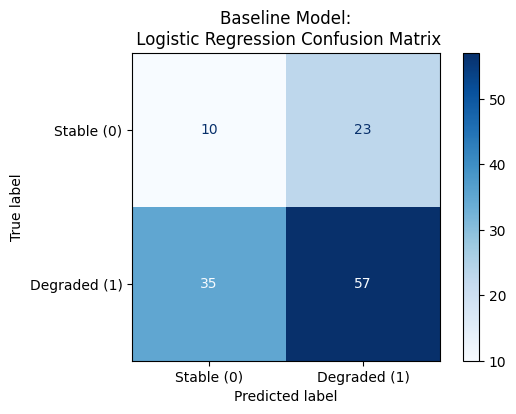

In [28]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix on test set predictions
matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=['Stable (0)', 'Degraded (1)'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, include_values=True, cmap=plt.cm.Blues)
ax.set_title('Baseline Model:\n Logistic Regression Confusion Matrix');

For a sanity check (and best practice), let's repeat with Stratified K-fold Cross-Validation

In [29]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)

In [30]:
from sklearn.model_selection import cross_val_score, cross_val_predict

accuracy = cross_val_score(lr_classifier, X_scaled, y, cv=cv, scoring='balanced_accuracy')
print(f'Mean balanced accuracy with cross-validation: {accuracy.mean():.4f}')

Mean balanced accuracy with cross-validation: 0.5714


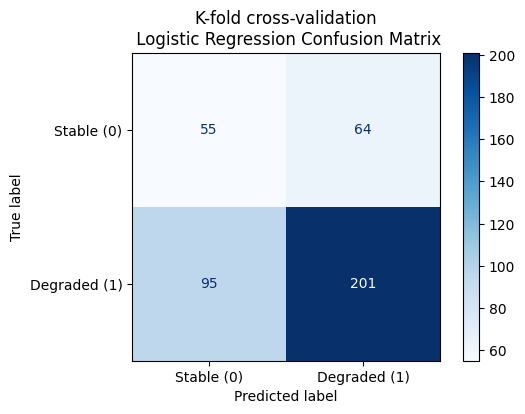

In [31]:
y_pred = cross_val_predict(lr_classifier, X_scaled, y, cv=cv)
matrix = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=['Stable (0)', 'Degraded (1)'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.set_title(f'K-fold cross-validation\n Logistic Regression Confusion Matrix');

### Discussion:

Using all default parameters for logistic regression except `class_weight='balanced'`, we achieved a mean balanced accuracy of 0.57. This means our baseline model is only slightly better than guessing which class is stable or degraded. This indicates the 4-mer feature set with 3'UTR length likely doesn't hold much information regarding stability of maternally derived mRNAs in P-granules during this phase of embroyonic development in C.elegans.

The next direction to explore is how well the data clusters following Principal Component Analysis (PCA) and t-distributed Stochastic Neighbor Embedding (t-SNE). This will allow us to visualize if dimensionality reduction can help distinguish which features are contributing to maximum explained variance, namely through PCA.


### PCA and t-SNE

In [32]:
X = kmers_df.drop(columns=['WBgene', 'label'])
y = kmers_df['label'].astype(int)
X.shape, y.shape

((415, 257), (415,))

In [33]:
X_scaled = StandardScaler().fit_transform(X)

Keep number of components that explain 95% of variance

In [34]:
from sklearn.decomposition import PCA

num_components = 0.95
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(415, 122)

#### Fig 2: PCA (kmer counts + UTR length)

PCA was able to reduce the dimensionality to 122 components while preserving 95% of explained variance in the dataset. This will likely improve the accuracy of the SVM model.

However, the PCA plot does not show a clear separation of data along PC1 or PC2.

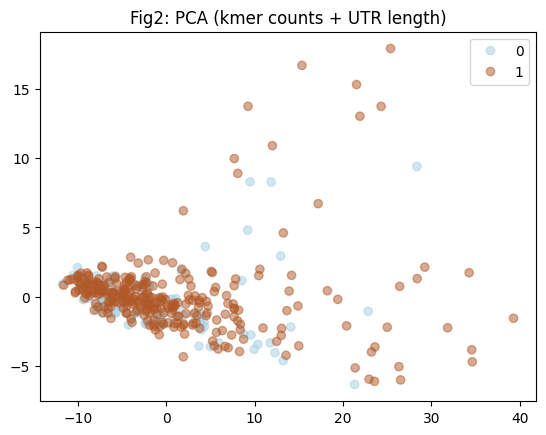

In [35]:
scatter=plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=y,
                    cmap=plt.cm.Paired)
plt.title('Fig2: PCA (kmer counts + UTR length)')
plt.legend(handles=scatter.legend_elements()[0], labels=range(2));

#### Fig 3: t-SNE (kmer counts + UTR length)

There still seems to be significant overlap between before classes in this feature set.

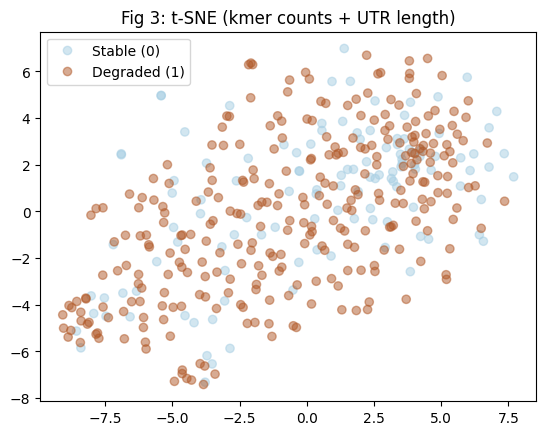

In [36]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=25).fit_transform(X_scaled)
scatter=plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, c=y,
                    cmap=plt.cm.Paired)
plt.title('Fig 3: t-SNE (kmer counts + UTR length)');
plt.legend(handles=scatter.legend_elements()[0], labels=['Stable (0)', 'Degraded (1)']);

### Support Vector Machine (SVM):

Since the logistic regression model with default parameters did a poor job classifying stable from degraded mRNAs, we would like to see if a baseline SVM model performs at a similar level.

Then, we can compare an SVM with hyperparameter tuning to the baseline model to see the model improves.

In [37]:
X = kmers_df.drop(columns=['WBgene', 'label'])
y = kmers_df['label'].astype(int)
X.shape, y.shape

((415, 257), (415,))

In [38]:
from sklearn.model_selection import StratifiedKFold

# Keep cv the same for SVM as for log regression
cv = StratifiedKFold(n_splits=10, random_state=1, shuffle=True)

In [39]:
from sklearn import svm
from sklearn.model_selection import cross_val_score

svm_cl = svm.SVC(kernel = 'rbf', class_weight='balanced')

accuracy = cross_val_score(svm_cl, X, y, cv=cv,
                           scoring='balanced_accuracy')

print(f"Mean accuracy with cross-validation: {np.mean(accuracy):.4f}")

Mean accuracy with cross-validation: 0.5825


# Baseline comparison:

| Model                        | Mean Accuracy |
|------------------------------|---------------|
| Logistic regression Baseline | 0.5714        |
| SVM Baseline (with rbf)      | 0.5825        |


### Discussion:

SVM with a non-linear rbf kernel with default hyperparameters performed marginally better when compared to logistic regression with default hyperparameters. The next step is to tune the model with cross-validation and grid search to find the optimal hyperparameter values for this model given the dataset.

# SVM: With Cross-validation and Grid Search

In [40]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm.SVC(kernel='rbf', class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='balanced_accuracy')
grid.fit(X, y)

print(f"Best params: {grid.best_params_}")
print(f"Best score:  {grid.best_score_:.4f}")

Best params: {'svm__C': 1, 'svm__gamma': 'scale'}
Best score:  0.6213


Make a `report` function to make notebook cleaner

In [41]:
def report(X, y, cv):
    """
    Takes X, y, and cv=cv to generate a report on model performance
    """
    from sklearn.metrics import classification_report
    y_pred = cross_val_predict(
        grid.best_estimator_,
        X,
        y,
        cv=cv
    )
    print(classification_report(y, y_pred))

In [42]:
report(X, y, cv=cv)

              precision    recall  f1-score   support

           0       0.42      0.55      0.47       119
           1       0.79      0.70      0.74       296

    accuracy                           0.65       415
   macro avg       0.61      0.62      0.61       415
weighted avg       0.69      0.65      0.66       415



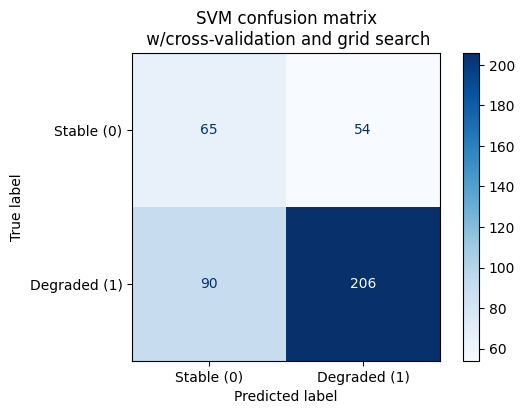

In [43]:
# Confusion matrix after grid search
y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

matrix = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=['Stable (0)', 'Degraded (1)'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.set_title('SVM confusion matrix\n '
             'w/cross-validation and grid search');

### With feature reduction via PCA

Marginal improvement: mean accuracy = 0.6217

The confusion matrix shows that there was an improvement on predicting degraded, but there was signal lost for predicting stable.

However, we are really interested in predicting which molecules persist in P-granules (i.e. stable). Mean accuracy in this sense is not as strong of a measurement to assess whether the model is doing a good job at predicting what persists in P-granules (stable).

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# PCA is inside the pipeline so it is refit on each CV fold's training data
# (fitting PCA on the full X before CV would leak validation-fold information).
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svm', svm.SVC(kernel='rbf', class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.01, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.001, 0.01, 0.1, 1.0]
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='balanced_accuracy')
grid.fit(X, y)

print(f"Best params: {grid.best_params_}")
print(f"Best score:  {grid.best_score_:.4f}")

Best params: {'svm__C': 1, 'svm__gamma': 0.01}
Best score:  0.6217


In [45]:
report(X, y, cv=cv)

              precision    recall  f1-score   support

           0       0.46      0.46      0.46       119
           1       0.78      0.78      0.78       296

    accuracy                           0.69       415
   macro avg       0.62      0.62      0.62       415
weighted avg       0.69      0.69      0.69       415



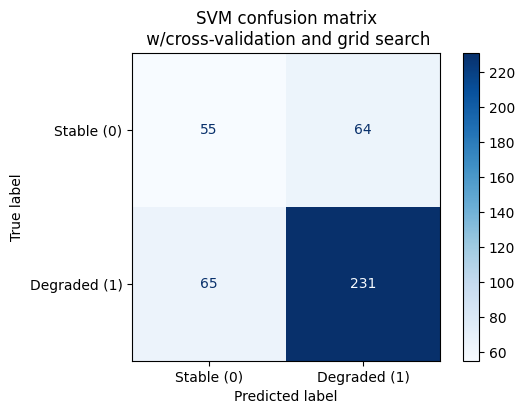

In [46]:
y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

matrix = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=['Stable (0)', 'Degraded (1)'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.set_title('SVM confusion matrix\n '
             'w/cross-validation and grid search');

## Results:

The confusion matrix shows that there was an improvement on predicting degraded, but there was signal lost for predicting stable.

This is indicating that feature reduction with PCA is pushing the model to predict the majority class.

In this case, we should look at the recall for SVM before and after PCA to see how well the model is predicting true positives.

### Accuracy:
| Model                                     | Accuracy | Metric|
|-------------------------------------------|----------|-------|
| Logistic regression Baseline              | 0.5714   | Mean
| SVM Baseline (with rbf)                   | 0.5825   | Mean
| SVM w/ hyperparameter tuning (before PCA) | 0.6213 | Best score |
| SVM w/ hyperparameter tuning (after PCA)  | 0.6246 | Best score |

### Recall (true positive rate):
| True / Predicted | positive            | negative            |
| :--------------- |:------------------- | :------------------ |
| **positive**     | true positive (TP)  | false negative (FN) |
| **negative**     | false positive (FP) | true negative (TN)  |


$$\mathrm{P} = \mathrm{TP} + \mathrm{FN}$$

$$
\mathrm {recall} =\frac {\mathrm {TP} }{\mathrm {P} }
=\frac {\mathrm {TP} }{\mathrm {TP} +\mathrm {FN} }
$$

### Recall Results:

As expected, the model improves at predicting the majority class, but performs worse at predicting the class we are more interested in (stable).

| Label            | Before PCA | After PCA |
|------------------|------------|-----------|
| **Stable (0)**   | 0.55       | 0.46      |
| **Degraded (1)** | 0.70       | 0.78      |



# Combined datasets

Sequence only information in the counts matrix does not seem to work well as a feature matrix for this model. It is likely due to sparsity (many counts with zero) and 3'UTR length confounding the results. The model is likely just learning that longer sequences have more k-mer counts. We already determined that the mean UTR length for the degraded class is longer than for the stable class.

So, we need to add more information into the model.

1) `kmers_df`: The 4-mer dataset merged with `UTR_length`

2) `mfe`: Minimum free energy for the mRNA secondary structures determined by the ViennaRNA package.
- https://github.com/ViennaRNA/ViennaRNA.git
- Executable program: RNAfold
- Calculate minimum free energy secondary structures and partition function of RNAs

3) `unp_df`: Average unpaired probabilities for locally stable secondary structures
- Also generated using ViennaRNA package
- Executable program: RNAplfold
- Generates a vector of pairing probabilities for each nucleotide position in the primary sequence
- This is adding structural information as regions with several low base-pairing probabilities represent regions with loop structures. Regions with consecutive high pairing probabilities represent regions with possible stem structures.

In [47]:
kmers_df.head(5)

,WBgene,label,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,...,ttct,ttga,ttgc,ttgg,ttgt,ttta,tttc,tttg,tttt,UTR_length
0,WBGene00010232,0,0,0,2,2,0,0,0,1,...,4,0,1,0,6,1,8,2,8,202.0
1,WBGene00007297,0,2,5,1,1,1,0,2,4,...,1,1,0,0,2,5,1,2,6,170.0
2,WBGene00017826,0,1,1,1,1,1,2,0,0,...,2,1,1,0,0,4,5,0,11,202.0
3,WBGene00003865,0,0,3,1,4,1,1,1,4,...,0,1,4,0,2,4,1,3,6,296.0
4,WBGene00007352,0,5,0,1,3,0,1,0,0,...,1,4,2,0,3,6,5,4,12,297.0


#### Let's look at the descriptive statistics for UTR length

Mean length is ~400 nucleotides

In [48]:
kmers_df['UTR_length'].describe()

count     415.000000
mean      399.024096
std       269.424695
min        43.000000
25%       211.000000
50%       331.000000
75%       500.000000
max      1492.000000
Name: UTR_length, dtype: float64

In [49]:
# read mfe dataset
mfe = pd.read_csv('rna_structure.csv')
mfe

,WBgene,MFE,MFE_normalized,paired_fraction,unpaired_fraction
0,WBGene00000041,-47.90,-0.175458,0.571429,0.428571
1,WBGene00000064,-22.50,-0.137195,0.475610,0.524390
2,WBGene00000098,-41.97,-0.118895,0.441926,0.558074
3,WBGene00000101,-53.90,-0.129257,0.465228,0.534772
4,WBGene00000168,-136.20,-0.176883,0.524675,0.475325
...,...,...,...,...,...
455,WBGene00022702,-73.60,-0.154947,0.517895,0.482105
456,WBGene00022703,-10.10,-0.094393,0.523364,0.476636
457,WBGene00022775,-77.10,-0.145198,0.451977,0.548023
458,WBGene00022832,-28.50,-0.123913,0.573913,0.426087


We only want MFE and paired_fraction columns

In [50]:
# Exclude MFE_normalized and unpaired_fraction
mfe = mfe.loc[:,['WBgene', 'MFE', 'paired_fraction']]
mfe.head(5)

,WBgene,MFE,paired_fraction
0,WBGene00000041,-47.90,0.571429
1,WBGene00000064,-22.50,0.475610
2,WBGene00000098,-41.97,0.441926
3,WBGene00000101,-53.90,0.465228
4,WBGene00000168,-136.20,0.524675


In [51]:
unp_df = pd.read_csv('lunp_feature_matrix.csv')

unp_df.head(5)

,WBgene,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,...,pos_1510,pos_1511,pos_1512,pos_1513,pos_1514,pos_1515,pos_1516,pos_1517,pos_1518,pos_1519
0,WBGene00000041,0.922297,0.941284,0.240469,0.394256,0.491847,0.621841,0.902658,0.916948,0.547302,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,WBGene00000064,0.836162,0.762144,0.746504,0.819049,0.919388,0.934912,0.931649,0.968136,0.802180,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,WBGene00000098,0.999781,0.979961,0.077575,0.312733,0.998578,0.997359,0.386887,0.295538,0.967880,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,WBGene00000101,0.976850,0.976360,0.997634,0.990108,0.494145,0.301994,0.160130,0.216985,0.285380,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,WBGene00000168,0.999333,0.987469,0.987348,0.982120,0.990047,0.943052,0.924567,0.174531,0.258878,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


75% of UTR length data is <= 500 nucleotides, and the max length is 1492 nucleotides. This means our dataset is highly sparce after 500 nucleotides. To increase signal, we need to reduce the sparcity in the dataset.

Let's retain the locally unpaired probabilities up to the mean sequence length 400

In [52]:
unp_df = unp_df.iloc[:, :400]

In [53]:
merged = (kmers_df
    .merge(mfe,        on='WBgene', how='inner')
    .merge(unp_df, on='WBgene', how='inner'))

In [54]:
X = merged.drop(columns=['WBgene', 'label'])
y = merged['label'].astype(int)

Still a lot of sparsity for short UTRs as shown in X.head

In [55]:
X.head(5)

,aaaa,aaac,aaag,aaat,aaca,aacc,aacg,aact,aaga,aagc,...,pos_390,pos_391,pos_392,pos_393,pos_394,pos_395,pos_396,pos_397,pos_398,pos_399
0,0,0,2,2,0,0,0,1,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,5,1,1,1,0,2,4,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,1,1,1,1,2,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,3,1,4,1,1,1,4,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0,1,3,0,1,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
X.shape, y.shape

((415, 658), (415,))

In [57]:
X_scaled = StandardScaler().fit_transform(X)
X_scaled

array([[-0.61422618, -0.88255583,  0.4195822 , ..., -0.64182116,
        -0.65756398, -0.66754517],
       [-0.43553437,  1.60901335, -0.20229856, ..., -0.64182116,
        -0.65756398, -0.66754517],
       [-0.52488027, -0.38424199, -0.20229856, ..., -0.64182116,
        -0.65756398, -0.66754517],
       ...,
       [-0.52488027, -0.38424199, -0.82417932, ..., -0.64182116,
        -0.65756398, -0.66754517],
       [ 1.70876732,  1.11069952,  0.4195822 , ...,  0.7511679 ,
        -0.07668804, -0.29446085],
       [-0.61422618, -0.88255583, -0.82417932, ..., -0.64182116,
        -0.65756398, -0.66754517]], shape=(415, 658))

In [58]:
num_components = 0.95
pca = PCA(n_components=num_components)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(415, 194)

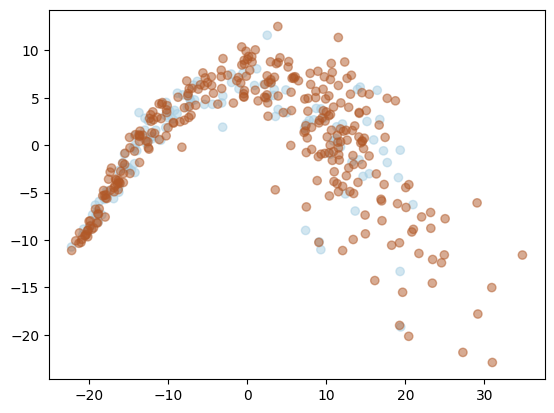

In [59]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=y, cmap=plt.cm.Paired);

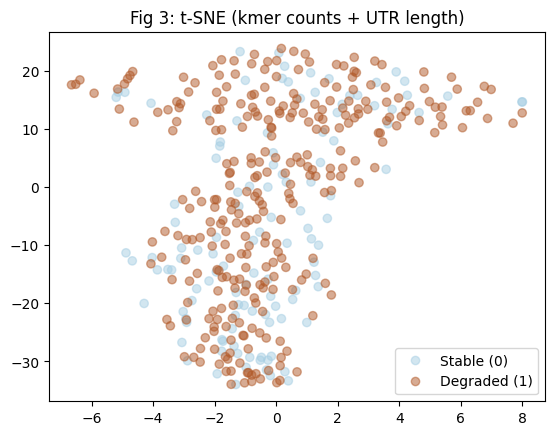

In [60]:
X_tsne = TSNE(n_components=2, perplexity=30).fit_transform(X_scaled)
scatter=plt.scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.5, c=y,
                    cmap=plt.cm.Paired)
plt.title('Fig 3: t-SNE (kmer counts + UTR length)');
plt.legend(handles=scatter.legend_elements()[0], labels=['Stable (0)', 'Degraded (1)']);

In [61]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', svm.SVC(kernel='rbf', class_weight='balanced'))
])

param_grid = {
    'svm__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'svm__gamma': ['scale', 'auto', 0.00001, 0.0001, 0.001, 0.01, 0.1]
}

grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
grid.fit(X, y)

print(f"Best params: {grid.best_params_}")
print(f"Best score:  {grid.best_score_:.4f}")

Best params: {'svm__C': 10.0, 'svm__gamma': 0.0001}
Best score:  0.6379


In [62]:
report(X, y, cv=cv)

              precision    recall  f1-score   support

           0       0.42      0.62      0.50       119
           1       0.81      0.65      0.72       296

    accuracy                           0.64       415
   macro avg       0.61      0.64      0.61       415
weighted avg       0.70      0.64      0.66       415



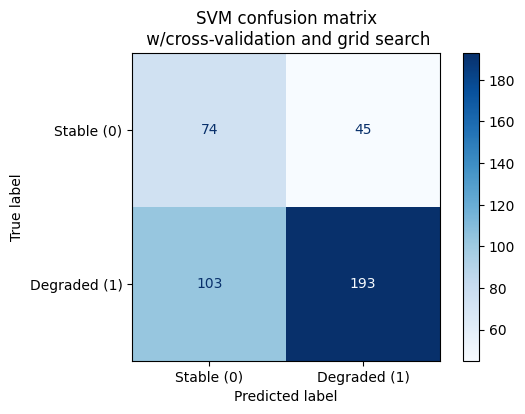

In [63]:
y_pred = cross_val_predict(grid.best_estimator_, X, y, cv=cv)

matrix = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matrix,
                              display_labels=['Stable (0)', 'Degraded (1)'])

fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.set_title('SVM confusion matrix\n '
             'w/cross-validation and grid search');

# Results:

### Table 1: Model Accuracy

| Model | Feature Set | Balanced Accuracy | Metric |
|-------|------------|:-----------------:|--------|
| Logistic Regression (Baseline, no CV) | k-mers + UTR length | 0.4610 | Single train/test split (70/30) |
| Logistic Regression (Baseline) | k-mers + UTR length | 0.5714 | Mean (10-fold stratified CV) |
| SVM Baseline (rbf kernel) | k-mers + UTR length | 0.5825 | Mean (10-fold stratified CV) |
| SVM w/ hyperparameter tuning | k-mers + UTR length (before PCA) | 0.6213 | Best score (grid search CV) |
| SVM w/ hyperparameter tuning | k-mers + UTR length (after PCA) | 0.6217 | Best score (grid search CV) |
| SVM w/ hyperparameter tuning | k-mers + UTR length + MFE + paired fraction + lunp | **0.6379** | Best score (grid search CV) |


### Table 2: Classification Report: SVM w/ hyperparameter tuning before PCA
#### k-mers + UTR length: C=1, gamma='scale'

| Class | Precision | Recall | F1-Score | Support |
|-------|:---------:|:------:|:--------:|:-------:|
| Stable (0) | 0.42 | 0.55 | 0.47 | 119 |
| Degraded (1) | 0.79 | 0.70 | 0.74 | 296 |
| Accuracy | | | 0.65 | 415 |
| Macro avg | 0.61 | 0.62 | 0.61 | 415 |
| Weighted avg | 0.69 | 0.65 | 0.66 | 415 |


### Table 3: Classification Report: SVM w/ hyperparameter tuning after PCA
#### k-mers + UTR length: C=1, gamma=0.01

| Class | Precision | Recall | F1-Score | Support |
|-------|:---------:|:------:|:--------:|:-------:|
| Stable (0) | 0.46 | 0.46 | 0.46 | 119 |
| Degraded (1) | 0.78 | 0.78 | 0.78 | 296 |
| Accuracy | | | 0.69 | 415 |
| Macro avg | 0.62 | 0.62 | 0.62 | 415 |
| Weighted avg | 0.69 | 0.69 | 0.69 | 415 |


### Table 4: Classification Report: SVM w/ hyperparameter tuning
#### Combined Features: k-mers + UTR length + MFE + paired fraction + lunp: C=10.0, gamma=0.0001

| Class | Precision | Recall | F1-Score | Support |
|-------|:---------:|:------:|:--------:|:-------:|
| Stable (0) | 0.42 | 0.62 | 0.50 | 119 |
| Degraded (1) | 0.81 | 0.65 | 0.72 | 296 |
| Accuracy | | | 0.64 | 415 |
| Macro avg | 0.61 | 0.64 | 0.61 | 415 |
| Weighted avg | 0.70 | 0.64 | 0.66 | 415 |


# Discussion

The best performing model in this analysis used the combined dataset: 4-mer counts, 3'UTR length, minimum free energy (MFE), paired fraction, and locally unpaired probabilities (lunp). It achieved a mean balanced accuracy of 0.6379 with 10-fold stratified cross-validation and grid search. This is meaningfully above the 0.5 chance baseline (stable or degraded), but far from a well performing classifier. The interpretation is that information within the primary structure of mRNA does carry some signal for predicting the stability of maternally derived mRNAs in P-granules, but this signal alone is not sufficient to reliably distinguish stable from degraded transcripts during early embryogenesis in *C. elegans*.

The progression of models in this analysis is informative. Non-linear SVM with default hyperparameters (0.5825) performed only marginally better than the logistic regression baseline (0.5714), indicating that a non-linear kernel and balanced class weighting alone added almost nothing to performance. Hyperparameter tuning improved this to 0.6213, and adding secondary structure features on top of the k-mer counts further improved performance to 0.6379. Each consecutive model had improved performance, but no single feature set carried a useful signal. This is consistent with the biological view that mRNA fate in P-granules is determined by interactions between sequence, structure, and trans-acting factors not captured by primary structure alone.

The comparison of SVM performance before and after PCA was the most informative interpretive result. Mean accuracy was nearly identical (0.6213 vs. 0.6217), but the per-class recall shifted noticeably. Recall on the stable class dropped from 0.55 to 0.46, while recall on the degraded class rose from 0.70 to 0.78. PCA retains components with the highest explained variance, and the directions that distinguish the minority (stable) class likely reside in some of the components that PCA discards, causing the model to predict more of the majority class. The combined-features model improved recall on the stable class to 0.62 (Table 4) This is a useful result since we are primarily interested in predicting which transcripts persist in P-granules rather than which are degraded. These results are consistent with the conclusion from Scholl et al. that P-granule association alone does not determine mRNA fate.

Future directions include extending the feature set beyond the 3'UTR. For example, codon usage in the coding sequence or known RNA-binding protein motifs. These would add information about the trans-acting factors that mediate post-transcriptional regulation. A larger labeled dataset would also likely allow the model to capture more informative signal.

To conclude, the primary structure of mRNA carries marginal information about P-granule stability in early *C. elegans* embryogenesis. Modeling this process more accurately will require feature sets that capture sequence, RNA structure, and the proteins that bind these transcripts within P-granules.